### Using quantum teleportation across a QPU

In [13]:
# Imports from Qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

import numpy as np

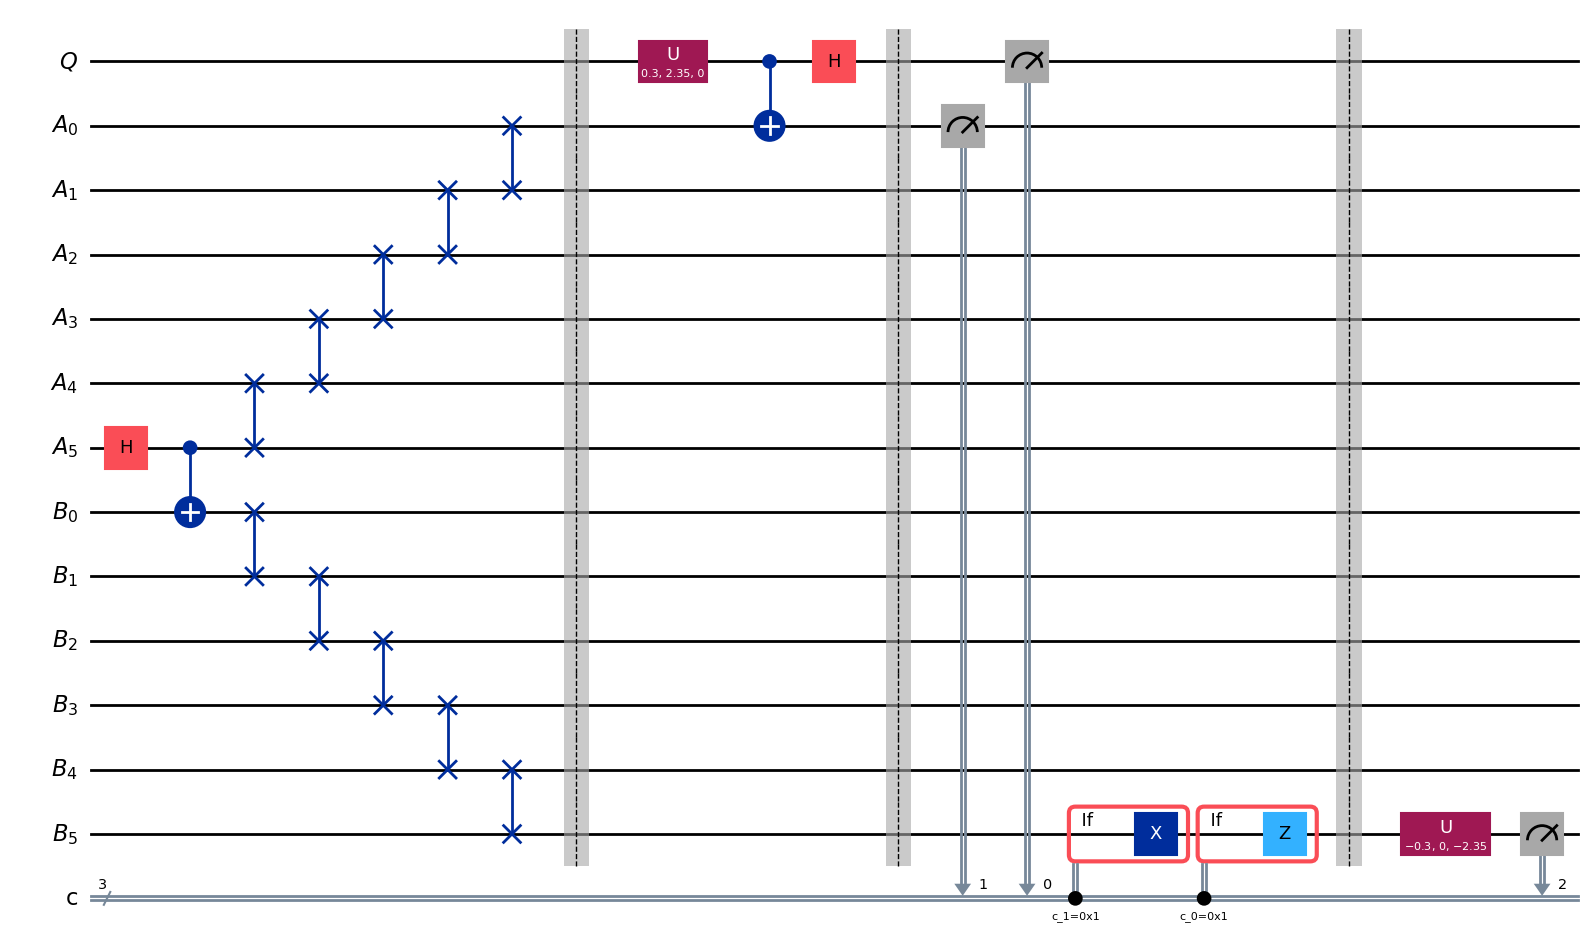

In [ ]:
 
# Define registers
qr = QuantumRegister(13, "q")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(qr, cr)
 
# Define registers
secret = QuantumRegister(1, "Q")
ebitsa = QuantumRegister(6, "A")
ebitsb = QuantumRegister(6, "B")
# q = ClassicalRegister(1, "q meas")
# a = ClassicalRegister(1, "a")
# b = ClassicalRegister(1, "b")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(secret, ebitsa, ebitsb, cr)
 
# We'll start Alice in the middle of the circuit, then move information outward in both directions.
Alice = 5
Bob = 0
qc.h(ebitsa[Alice])
qc.cx(ebitsa[Alice], ebitsb[Bob])
 
# Starting with Bob and Alice in the center, we swap their information onto adjacent qubits, until the information is on distant qubits.
 
for n in range(Alice):
    qc.swap(ebitsb[Bob], ebitsb[Bob + 1])
    qc.swap(ebitsa[Alice], ebitsa[Alice - 1])
    Alice = Alice - 1
    Bob = Bob + 1
 
qc.barrier()
 
# Create a random state for Alice (qubit zero)
np.random.seed(42)  # fixing seed for repeatability
# theta = np.random.uniform(0.0, 1.0) * np.pi    #from 0 to pi
theta = 0.3
varphi = np.random.uniform(0.0, 2.0) * np.pi  # from 0 to 2*pi
qc.u(theta, varphi, 0.0, secret)
 
# Entangle Alice's two qubits
qc.cx(secret, ebitsa[Alice])
qc.h(secret)
 
qc.barrier()
 
# Make measurements of Alice's qubits and store the results in the classical register.
qc.measure(ebitsa[Alice], cr[1])
qc.measure(secret, cr[0])
 
# Send instructions to Bob's qubits based on the outcome of Alice's measurements.
with qc.if_test((cr[1], 1)):
    qc.x(ebitsb[Bob])
with qc.if_test((cr[0], 1)):
    qc.z(ebitsb[Bob])
 
qc.barrier()
 
# Invert the preparation we did for Carl's qubit so we can check whether we did this correctly.
qc.u(theta, varphi, 0.0, ebitsb[Bob]).inverse()  # inverse of u(theta,varphi,0.0)
qc.measure(ebitsb[Bob], cr[2])  # add measurement gate
 
qc.draw("mpl")

In [9]:
# Find least busy backend and create a Sampler instance
service = QiskitRuntimeService()
print("")
backend = service.least_busy()
print(f"Least busy backend: {backend.name}")
print(f"Has {backend.status().pending_jobs} pending jobs.")

qiskit_runtime_service.__init__:WARNING:2025-11-18 11:56:32,650: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: eloza. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


qiskit_runtime_service.backends:WARNING:2025-11-18 11:56:33,273: Using instance: eloza, plan: open


Least busy backend: ibm_fez
Has 0 pending jobs.


In [11]:
# use a preset pass manager to optimize our quantum circuit for the selected backend
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
 
qc_isa_zero = pm.run(qc)

# check the depth of the transpiled circuit
print("The total depth is ", qc_isa_zero.depth())
print(
    "The depth of two-qubit gates is ",
    qc_isa_zero.depth(lambda instruction: instruction.operation.num_qubits == 2),
)

The total depth is  21
The depth of two-qubit gates is  2


In [12]:
# Create a Sampler job to run the circuit and save the job ID
sampler = Sampler(mode=backend)
job = sampler.run([qc_isa_zero])
job_id = job.job_id()
print(f"Job ID: {job_id}")

Job ID: d4e52o6lo8as739n9svg


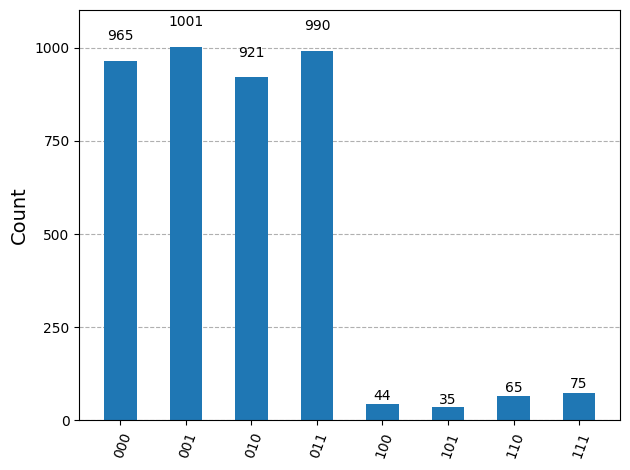

In [14]:
# plot results

# job_id = "d4e4ec4nntuc73abpvqg"
job = service.job(job_id)
res = job.result()
counts = res[0].data.c.get_counts()

plot_histogram(counts)